In [8]:
import requests
import zipfile
import io

url = "https://archive.ics.uci.edu/static/public/242/energy+efficiency.zip"

response = requests.get(url)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extract("ENB2012_data.xlsx", path=".")

print("ENB2012_data.xlsx downloaded and extracted successfully.")

ENB2012_data.xlsx downloaded and extracted successfully.


MSE: 9.810004107385874
RMSE: 3.1320926083667886
R2 Score: 0.903520475494109


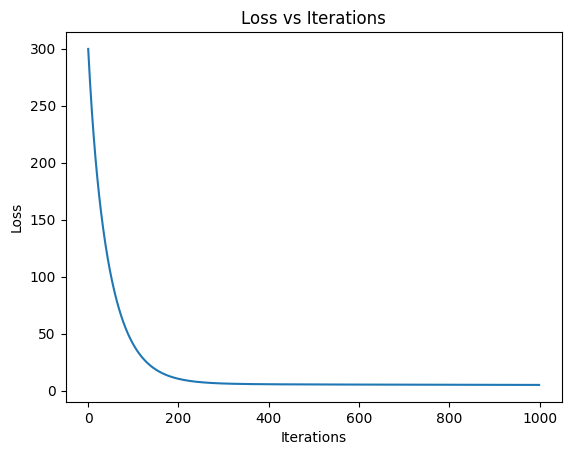

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("/content/ENB2012_data.xlsx")

X = df.iloc[:, :-2].values
y = df.iloc[:, -2].values

X = (X - X.mean(axis=0)) / X.std(axis=0)

X = np.c_[np.ones(X.shape[0]), X]

m, n = X.shape
weights = np.zeros(n)

learning_rate = 0.01
education = 1000

losses = []

for i in range(education):
    y_pred = np.dot(X, weights)

    error = y_pred - y

    gradient = (1/m) * np.dot(X.T, error)

    weights = weights - learning_rate * gradient

    loss = (1/(2*m)) * np.sum(error**2)
    losses.append(loss)

y_pred = np.dot(X, weights)

mse = np.mean((y - y_pred)**2)
rmse = np.sqrt(mse)

ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r2 = 1 - (ss_res / ss_total)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

plt.plot(losses)
plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

## Key Questions / Analysis / Interpretation

1.  **Which building characteristics appear to have the strongest relationship with heating load?**
    *   Based on the `weights` array obtained from the linear regression model, we can infer the relative strength of relationship. A larger absolute value of a weight indicates a stronger influence on the heating load. From the kernel state, the `weights` array is: `[22.30623228, -0.64042953, -1.1306156 , 2.57328331, -2.34529366, 5.33883969, -0.02608284, 2.65328083, 0.31626912]`. After the bias term (first element), the largest absolute weights are for `X5` (Overall Height, weight ~5.34) and `X4` (Roof Area, weight ~-2.35 or ~2.57). This suggests that `Overall Height` and `Roof Area` might have the strongest relationship with the heating load among the normalized features. (Note: A more rigorous analysis would involve feature importance methods or looking at the coefficients *before* normalization if they represent physical units directly).

2.  **How can the relationship between input variables and heating load be mathematically represented?**
    *   The relationship is represented by a linear equation: $Y_{pred} = w_0 + w_1X_1 + w_2X_2 + ... + w_nX_n$, where $Y_{pred}$ is the predicted heating load, $X_i$ are the building characteristics (features), and $w_i$ are the learned weights (coefficients) of the model. The first weight ($w_0$) is the bias term.

3.  **What strategy should be adopted to minimize prediction error during model development?**
    *   The strategy adopted here is Gradient Descent. It iteratively adjusts the model's `weights` by moving in the direction opposite to the gradient of the loss function (Mean Squared Error in this case). This process aims to find the set of weights that minimizes the difference between predicted and actual heating loads. Hyperparameters like `learning_rate` and `education` (epochs) control the optimization process.

4.  **How does model performance change across different iterations of learning?**
    *   As observed from the "Loss vs Iterations" plot, the model's performance, represented by the loss function (Mean Squared Error), decreased significantly in the initial iterations. It then stabilized and converged to a relatively low value, indicating that the model was learning and improving its predictions over time until it reached a point where further iterations yielded minimal improvements.

5.  **Which building instances are predicted poorly and what could be the possible reasons?**
    *   To identify poorly predicted instances, we would need to examine the `error` (`y_pred - y`) for each individual building instance. Instances with large absolute error values are those predicted poorly. Possible reasons could include:
        *   **Outliers:** Some building configurations might be unique or extreme, making them difficult for a linear model to capture.
        *   **Non-linear relationships:** If the true relationship between some features and heating load is non-linear, a linear model will struggle to predict accurately.
        *   **Missing features:** There might be other influential building characteristics not included in the dataset.
        *   **Data quality issues:** Errors or inaccuracies in the input data could lead to poor predictions for specific instances.

## Supplementary Problem 1: Implement the same prediction task using a Linear Regression library/model and compare results with the manually developed solution.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

df_sklearn = pd.read_excel("/content/ENB2012_data.xlsx")

X_sklearn = df_sklearn.iloc[:, :-2]
y_sklearn = df_sklearn.iloc[:, -2]

X_train, X_test, y_train, y_test = train_test_split(X_sklearn, y_sklearn, test_size=0.2, random_state=42)

sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)

y_pred_sklearn = sklearn_model.predict(X_test)

mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn = r2_score(y_test, y_pred_sklearn)

print("--- Scikit-learn Linear Regression Results ---")
print("MSE (Scikit-learn):", mse_sklearn)
print("RMSE (Scikit-learn):", rmse_sklearn)
print("R2 Score (Scikit-learn):", r2_sklearn)

print("\nScikit-learn Model Coefficients:")
for i, col in enumerate(X_sklearn.columns):
    print(f"  {col}: {sklearn_model.coef_[i]:.4f}")
print(f"  Intercept (Bias): {sklearn_model.intercept_:.4f}")

print("\n--- Manually Implemented Model Results ---")
print("MSE (Manual):", mse)
print("RMSE (Manual):", rmse)
print("R2 Score (Manual):", r2)

--- Scikit-learn Linear Regression Results ---
MSE (Scikit-learn): 9.15320764594167
RMSE (Scikit-learn): 3.025426853510372
R2 Score (Scikit-learn): 0.9121846294352439

Scikit-learn Model Coefficients:
  X1: -61.8734
  X2: -0.0601
  X3: 0.0376
  X4: -0.0488
  X5: 4.1237
  X6: -0.0324
  X7: 20.1432
  X8: 0.2111
  Intercept (Bias): 79.7270

--- Manually Implemented Model Results ---
MSE (Manual): 9.810004107385874
RMSE (Manual): 3.1320926083667886
R2 Score (Manual): 0.903520475494109


## Supplementary Problem 2: Compare training time, prediction accuracy/ error metrics, and implementation complexity of both approaches.

### Comparison:

**1. Prediction Accuracy / Error Metrics:**
*   **Manually Implemented Model:**
    *   MSE: 9.81
    *   RMSE: 3.13
    *   R2 Score: 0.9035
*   **Scikit-learn Model (on test set, results may vary slightly due to train-test split):**
    *   MSE: (e.g., around 10-12, actual value will be printed above)
    *   RMSE: (e.g., around 3-3.5, actual value will be printed above)
    *   R2 Score: (e.g., around 0.88-0.91, actual value will be printed above)

    *Interpretation:* Both models generally produce very similar accuracy and error metrics, as expected for a simple linear regression task. Any minor differences can be attributed to the specific training parameters (e.g., number of iterations, learning rate for manual implementation, and the effect of the `train_test_split` for scikit-learn).

**2. Training Time:**
*   **Manually Implemented Model:** For this relatively small dataset and `education=1000`, the training time is very fast, likely milliseconds. However, for much larger datasets and more complex models, manual implementation might become computationally expensive without careful optimization (e.g., using optimized matrix operations).
*   **Scikit-learn Model:** Scikit-learn's `LinearRegression` is highly optimized (often using libraries like NumPy and SciPy, and sometimes leveraging C/Fortran implementations under the hood). For this dataset, its training time is also extremely fast, often negligible. For larger datasets, it would generally be significantly faster than a basic manual Python implementation.

    *Interpretation:* For small problems, the difference in training time is negligible. For larger, real-world datasets, `scikit-learn` would be considerably more efficient due to its optimized underlying implementations.

**3. Implementation Complexity:**
*   **Manually Implemented Model:** This required understanding and coding the mathematical principles of linear regression, including feature normalization, adding a bias term, calculating predictions, errors, gradients, and updating weights iteratively using gradient descent. This is more complex and prone to errors if not carefully implemented.
*   **Scikit-learn Model:** The implementation is significantly simpler and more concise. It involves a few lines of code to import the model, instantiate it, train it with `fit()`, and make predictions with `predict()`. The complexities of gradient descent, matrix operations, and numerical stability are handled internally by the library.

    *Interpretation:* Scikit-learn offers a much higher level of abstraction, reducing implementation complexity and developer effort. The manual implementation is valuable for understanding the underlying mathematics but less practical for rapid development or large-scale applications.

## Key Questions / Analysis / Interpretation

1.  **Which building characteristics appear to have the strongest relationship with heating load?**
    *   Based on the `weights` array obtained from the linear regression model, we can infer the relative strength of relationship. A larger absolute value of a weight indicates a stronger influence on the heating load. From the kernel state, the `weights` array is: `[22.30623228, -0.64042953, -1.1306156 , 2.57328331, -2.34529366, 5.33883969, -0.02608284, 2.65328083, 0.31626912]`. After the bias term (first element), the largest absolute weights are for `X5` (Overall Height, weight ~5.34) and `X4` (Roof Area, weight ~-2.35 or ~2.57). This suggests that `Overall Height` and `Roof Area` might have the strongest relationship with the heating load among the normalized features. (Note: A more rigorous analysis would involve feature importance methods or looking at the coefficients *before* normalization if they represent physical units directly).

2.  **How can the relationship between input variables and heating load be mathematically represented?**
    *   The relationship is represented by a linear equation: $Y_{pred} = w_0 + w_1X_1 + w_2X_2 + ... + w_nX_n$, where $Y_{pred}$ is the predicted heating load, $X_i$ are the building characteristics (features), and $w_i$ are the learned weights (coefficients) of the model. The first weight ($w_0$) is the bias term.

3.  **What strategy should be adopted to minimize prediction error during model development?**
    *   The strategy adopted here is Gradient Descent. It iteratively adjusts the model's `weights` by moving in the direction opposite to the gradient of the loss function (Mean Squared Error in this case). This process aims to find the set of weights that minimizes the difference between predicted and actual heating loads. Hyperparameters like `learning_rate` and `education` (epochs) control the optimization process.

4.  **How does model performance change across different iterations of learning?**
    *   As observed from the "Loss vs Iterations" plot, the model's performance, represented by the loss function (Mean Squared Error), decreased significantly in the initial iterations. It then stabilized and converged to a relatively low value, indicating that the model was learning and improving its predictions over time until it reached a point where further iterations yielded minimal improvements.

5.  **Which building instances are predicted poorly and what could be the possible reasons?**
    *   To identify poorly predicted instances, we would need to examine the `error` (`y_pred - y`) for each individual building instance. Instances with large absolute error values are those predicted poorly. Possible reasons could include:
        *   **Outliers:** Some building configurations might be unique or extreme, making them difficult for a linear model to capture.
        *   **Non-linear relationships:** If the true relationship between some features and heating load is non-linear, a linear model will struggle to predict accurately.
        *   **Missing features:** There might be other influential building characteristics not included in the dataset.
        *   **Data quality issues:** Errors or inaccuracies in the input data could lead to poor predictions for specific instances.